# Pricing - Greek - PnL Explain

## Step 0 - Importing packages

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

sns.set(style="whitegrid")

## Step 1 - Black-Scholes implementation

$$C(S,t) = S\times N(d_1) - Ke^{-r \times T}N(d_2)$$
$$d_1 = \frac{ln(\frac{S}{K}) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}} \quad ; \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [7]:
def black_scholes_prices(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    else:
        raise ValueError("Type must be 'call' or 'put'!")

    return price

In [8]:
# Quick test
black_scholes_prices(100, 105, 1, 0.01, 0.2, "call")

6.297254539086033

## Step 2 - Greek implementation

**Delta $\Delta$**: Measure the rate of change in an option’s price relative to a one-point move in the underlying asset. 
$$\Delta = \frac{\delta C}{\delta S} = N(d_1)$$
**Gamma $\Gamma$**: Measure the rate of change in delta per one-point move in the underlying asset. 
$$\Gamma = \frac{\delta \Delta}{\delta S} = \frac{\delta^2 C}{\delta S^2} = \frac{N'(d_1)}{S \sigma \sqrt{T}}$$
**Vega $\mathcal{V}$**: Measure how much volatility affects an option’s value. 
$$\mathcal{V} = \frac{\delta C}{\delta \sigma} = S \sqrt{T} N'(d_1)$$
**Theta $\theta$**: Measure how much time decay affects an option’s value over a one day period.
$$\theta_{call} = \frac{\delta C}{\delta T} = -\frac{S \sigma N'(d_1)}{2 \sqrt{T}} - rKe^{-rT}N(d_2)$$
$$\theta_{put} = \frac{\delta C}{\delta T} = -\frac{S \sigma N'(d_1)}{2 \sqrt{T}} + rKe^{-rT}N(-d_2)$$
**Rho $\rho$**: Measure how much interest rates affect an option’s value.
$$\rho_{call} = \frac{\delta C}{\delta r} = KTe^{-rT}N(d_2)$$
$$\rho_{put} = \frac{\delta C}{\delta r} = -KTe^{-rT}N(-d_2)$$

In [54]:
def delta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    if option_type == "call":
        return norm.cdf(d1)
    elif option_type == "put":
        return norm.cdf(d1) - 1
    else:
        raise ValueError("Type must be 'call' or 'put'!")

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return norm.pdf(d1)/(S*sigma*np.sqrt(T))

def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return S * np.sqrt(T) * norm.pdf(d1)

def theta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return -(S*sigma*norm.pdf(d1))/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        return -(S*sigma*norm.pdf(d1))/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)
    else:
        raise ValueError("Type must be 'call' or 'put'!")

def rho(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return K*T*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        return -K*T*np.exp(-r*T)*norm.cdf(-d2)
    else:
        raise ValueError("Type must be 'call' or 'put'!")

## Step 3 - Plot 5 Greeks

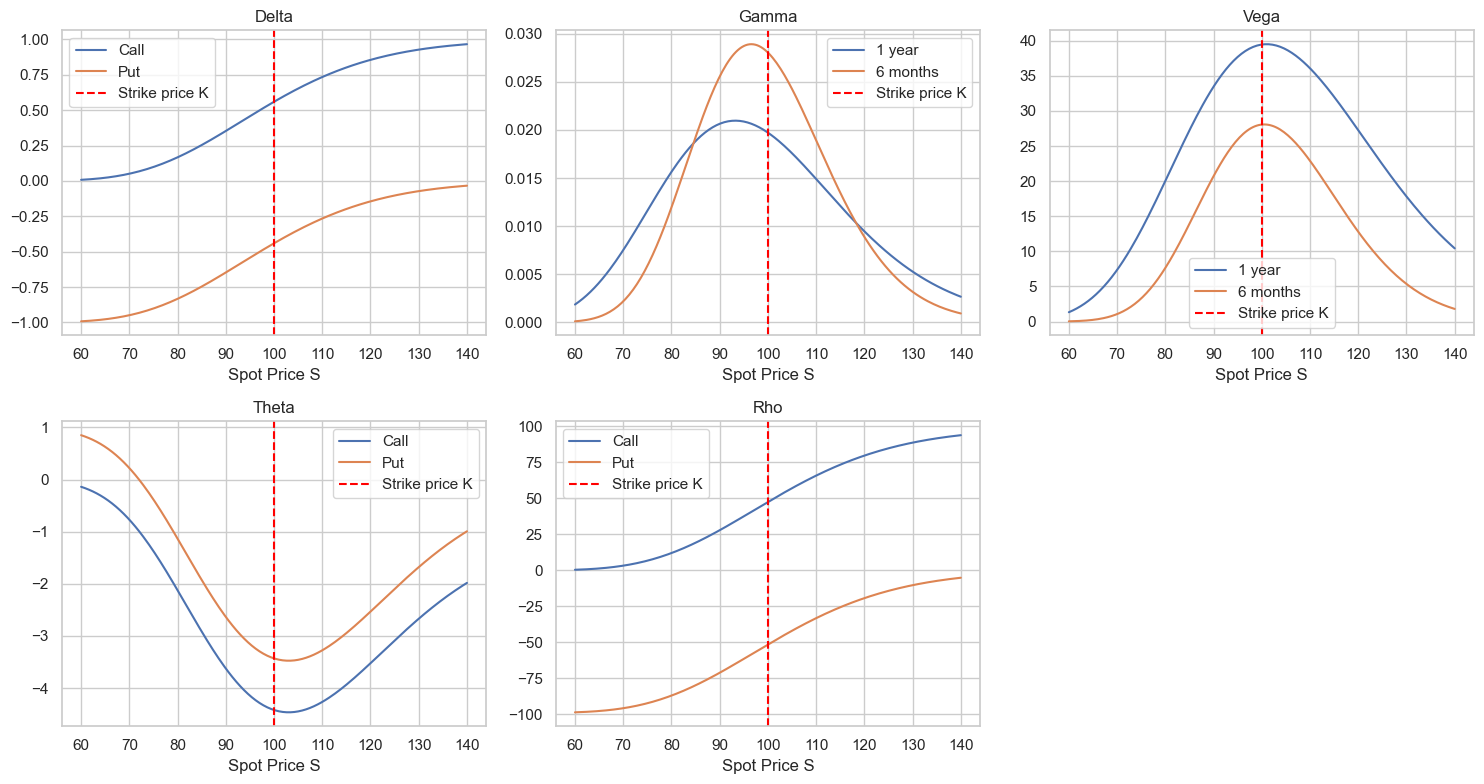

In [13]:
# Parameters
K = 100
T = 1
r = 0.01
sigma = 0.2

# Compute greeks for a series of S (call & put)
S_range = np.linspace(60,140,200)
delta_vals = [delta(S, K, T, r, sigma, option_type="call") for S in S_range]
delta_vals_put = [delta(S, K, T, r, sigma, option_type="put") for S in S_range]
gamma_vals = [gamma(S, K, T, r, sigma) for S in S_range]
gamma_vals_6m = [gamma(S, K, 0.5, r, sigma) for S in S_range]
vega_vals = [vega(S, K, T, r, sigma) for S in S_range]
vega_vals_6m = [vega(S, K, 0.5, r, sigma) for S in S_range]
theta_vals = [theta(S, K, T, r, sigma, option_type="call") for S in S_range]
theta_vals_put = [theta(S, K, T, r, sigma, option_type="put") for S in S_range]
rho_vals = [rho(S, K, T, r, sigma, option_type="call") for S in S_range]
rho_vals_put = [rho(S, K, T, r, sigma, option_type="put") for S in S_range]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax in axes.flat:
    ax.set_xlabel("Spot Price S")

# ---- Delta ----
axes[0,0].plot(S_range, delta_vals, label = "Call")
axes[0,0].plot(S_range, delta_vals_put, label = "Put")
axes[0,0].axvline(K, linestyle = "--", color = "red", label = "Strike price K")
axes[0,0].set_title("Delta")
axes[0,0].legend()

# ---- Gamma ----
axes[0,1].plot(S_range, gamma_vals, label = "1 year")
axes[0,1].plot(S_range, gamma_vals_6m, label = "6 months")
axes[0,1].axvline(K, linestyle = "--", color = "red", label = "Strike price K")
axes[0,1].set_title("Gamma")
axes[0,1].legend()

# ---- Vega ----
axes[0,2].plot(S_range, vega_vals, label = "1 year")
axes[0,2].plot(S_range, vega_vals_6m, label = "6 months")
axes[0,2].axvline(K, linestyle = "--", color = "red", label = "Strike price K")
axes[0,2].set_title("Vega")
axes[0,2].legend()

# ---- Theta ----
axes[1,0].plot(S_range, theta_vals, label = "Call")
axes[1,0].plot(S_range, theta_vals_put, label = "Put")
axes[1,0].axvline(K, linestyle = "--", color = "red", label = "Strike price K")
axes[1,0].set_title("Theta")
axes[1,0].legend()

# ---- Rho ----
axes[1,1].plot(S_range, rho_vals, label = "Call")
axes[1,1].plot(S_range, rho_vals_put, label = "Put")
axes[1,1].axvline(K, linestyle = "--", color = "red", label = "Strike price K")
axes[1,1].set_title("Rho")
axes[1,1].legend()

# Remove empty subplot
axes[1,2].axis("off")
plt.tight_layout()
plt.show()

**Delta**: 
- Range: 0 to 1 for a call, and -1 to 0 for a put.
- For a call: When out-of-the-money (S << K), delta is close to 0 => that means \\$1 move in the stock has almost no effect on the call price (option is worthless); when at-the-money (S = K), delta is approximately 0.5 ( \\$1 rise in the stock == \$0.5 increase in the option ); when in-the-money (S >> K), delta is 1, so the call behaves exactly like owning the underlying stock.
- For a put: When OTM (S >> K), delta is close to 0, option doesn't react to stock price movements; when at-the-money (S = K), delta is approximately -0.5 (\\$1 rise in the stock == \\$0.5 decrease in the option ); when in-the-money (S << K), delta is -1, so a drop of \\$1 in the stock price adds \\$1 to the put's value.

**Gamma**:
- Gamma is the highest when near the strike price K (This is where Delta is the most sensitive - ATM).
- OTM/ITM : Gamma drops to 0, Delta is unlikely to change.
- The peak will be taller and narrower for short maturity, in order to capture the volatility of the option price.

**Vega**:
- Symmetry for call & put, because both options benefit from increased volatility (which increases the probability of ITM).
- Peak ATM at strike price K.
- OTM/ITM: Vega falls to 0, a change in volatility doesn't affect the option price.
- Unlike Gamma, Vega decreases as expiration approaches since there is less time for volatility to impact the outcome.

**Theta**:
- Negative values: Expenses for option holder.
- Peak ATM at K, because having the most time premium to lose.
- Call is lower than put:
    - Due to interest rate (r), because carrying a stock costs money (interest) and call option (same as having stock) carries this cost.
    - If put theta is positive, the option gains value as time passes

## Step 4 - Full P&L Explain

$$P\&L \approx \Delta dS + \frac{1}{2} \Gamma dS^2 + \mathcal{V} d\sigma + \theta dt + \rho dr$$

In [17]:
# Parameters
S = 100
K = 100
T = 1
r = 0.01
sigma = 0.2
dS = 2
dsigma = 0.02
dr = 0.001
dt = 1/252

# Compute price vs greeks
price_0 = black_scholes_prices(S, K, T, r, sigma, "call")
delta_0 = delta(S, K, T, r, sigma, "call")
gamma_0 = gamma(S, K, T, r, sigma)
vega_0 = vega(S, K, T, r, sigma)
theta_0 = theta(S, K, T, r, sigma, "call")
rho_0 = rho(S, K, T, r, sigma, "call")

# Estimate P&L
pnl_delta_gamma = delta_0*dS + 0.5*gamma_0*dS**2 
pnl_vega = delta_0*dS + 0.5*gamma_0*dS**2 + vega_0*dsigma 
pnl_theta = delta_0*dS + 0.5*gamma_0*dS**2 + vega_0*dsigma + theta_0*dt 
pnl_full = delta_0*dS + 0.5*gamma_0*dS**2 + vega_0*dsigma + theta_0*dt + rho_0*dr

# Compute the exact P&L
price_1 = black_scholes_prices(S+dS, K, T+dt, r+dr, sigma+dsigma, "call")
pnl_exact = price_1 - price_0

# Display
print("P&L explained by Delta-Gamma:", pnl_delta_gamma)
print("P&L explained by Delta-Gamma-Vega:", pnl_vega)
print("P&L explained by Delta-Gamma-Vega-Theta:", pnl_theta)
print("P&L explained by 5 Greeks:", pnl_full)
print("Exact P&L:", pnl_exact)

P&L explained by Delta-Gamma: 1.1586833178312739
P&L explained by Delta-Gamma-Vega: 1.9476419796470519
P&L explained by Delta-Gamma-Vega-Theta: 1.9301019883194803
P&L explained by 5 Greeks: 1.977630438866395
Exact P&L: 2.017564823191684


Vega has a high impact on the estimation. P&L is best explained by all 5 Greeks.

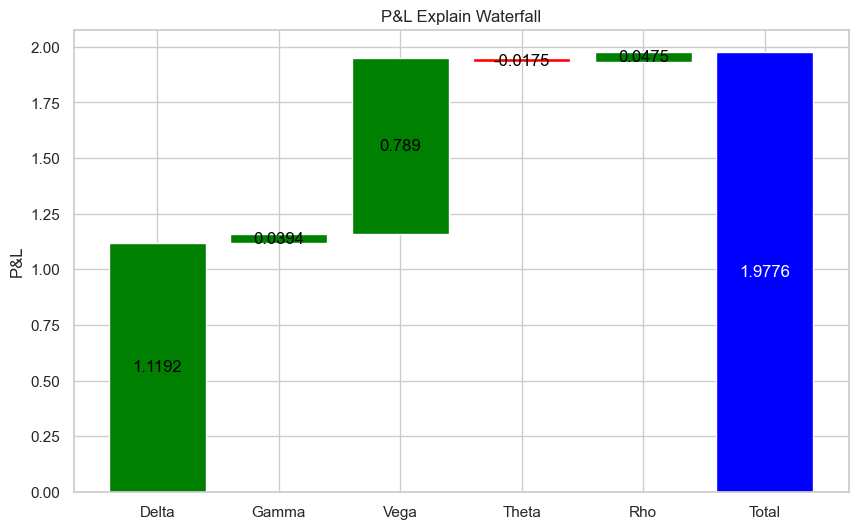

In [19]:
#---- Waterfall contribution plot ----

# Dictionary of contributions
contributions = {
    "Delta": delta_0 * dS,
    "Gamma": 0.5 * gamma_0 * dS**2,
    "Vega": vega_0 * dsigma,
    "Theta": theta_0 * dt,
    "Rho": rho_0 * dr
}

# Extract from dictionary
labels = list(contributions.keys())
values = list(contributions.values())

# Cumulative positions
cumulative = np.cumsum([0] + values[:-1]) # 0 in the beginning, omit the last of values

# Vector of color
color = ["green" if v >= 0 else "red" for v in values]

# Bar plot of each Greek
plt.figure(figsize=(10,6))
for i in range(len(values)):
    plt.bar(labels[i], values[i], bottom=cumulative[i], color=color[i])
    plt.text(i, cumulative[i]+values[i]/2, round(values[i],4), ha="center", va="center", color="black")

# Total bar
total_pnl = sum(values)
plt.bar("Total", total_pnl, color="blue")
plt.text(len(values), total_pnl/2, round(total_pnl,4), ha="center", va="center", color="white")
plt.title("P&L Explain Waterfall")
plt.ylabel("P&L")
plt.show()

## Step 5 - Sensitivity Comparison for P&L and Error Analysis

### 5.1 - Sensitivity to Spot price (Delta & Gamma)

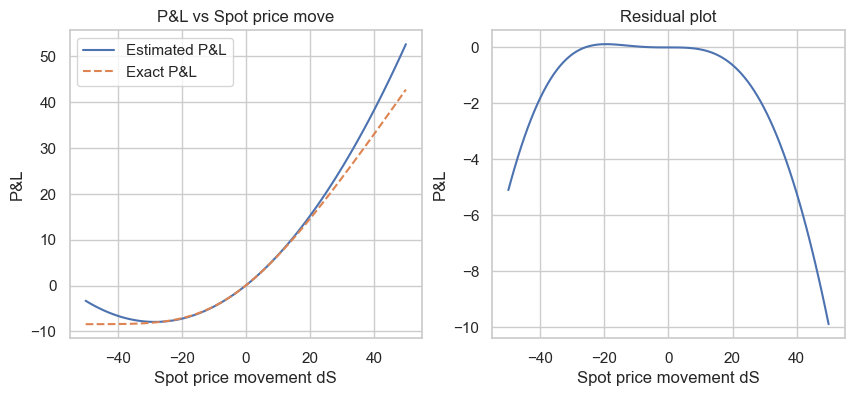

In [22]:
# Parameters
S = 100
K = 100
T = 1
r = 0.01
sigma = 0.2
dS_range = np.linspace(-50,50,100)

# Compute Greeks
price_0 = black_scholes_prices(S, K, T, r, sigma, "call")
price_1 = black_scholes_prices(S+dS_range, K, T, r, sigma, "call")
delta_0 = delta(S, K, T, r, sigma, "call")
gamma_0 = gamma(S, K, T, r, sigma)

# Compute P&L
pnl_estimate = delta_0 *dS_range + 0.5 * gamma_0 * dS_range**2
pnl_exact = price_1 - price_0

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(dS_range, pnl_estimate, label = "Estimated P&L")
plt.plot(dS_range, pnl_exact, linestyle = "--", label = "Exact P&L")
plt.title("P&L vs Spot price move")
plt.xlabel("Spot price movement dS")
plt.ylabel("P&L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dS_range, pnl_exact - pnl_estimate)
plt.title("Residual plot")
plt.xlabel("Spot price movement dS")
plt.ylabel("P&L")
plt.show()

- For small movement of spot, the P&L estimatation captures almost 100% of the price action.
- Usually, the vanilla option is relatively smooth so the quadratic estimation by Delta and Gamma is a very good fit for Black-Scholes curve near the current price.
- Erreur ~ 0 for small shocks

### 5.2 - Sensitivity to the volatility (Vega)

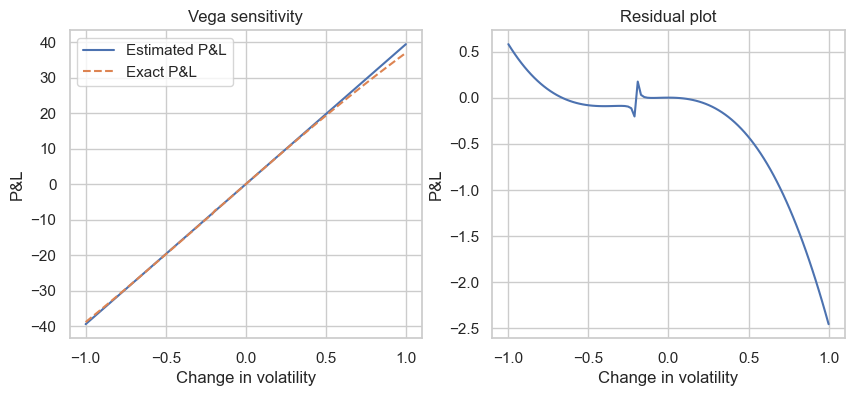

In [25]:
# Parameters
S = 100
K = 100
T = 1
r = 0.01
sigma = 0.2
dsigma_range = np.linspace(-1,1,100)

# Compute P&L
price_0 = black_scholes_prices(S, K, T, r, sigma, "call")
price_1 = black_scholes_prices(S, K, T, r, sigma+dsigma_range, "call")
pnl_exact = price_1 - price_0
pnl_estimate = [vega(S,K,T,r,sigma)*ds for ds in dsigma_range]

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(dsigma_range, pnl_estimate, label = "Estimated P&L")
plt.plot(dsigma_range, pnl_exact, linestyle = "--", label = "Exact P&L")
plt.title("Vega sensitivity")
plt.xlabel("Change in volatility")
plt.ylabel("P&L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dsigma_range, pnl_exact - pnl_estimate)
plt.title("Residual plot")
plt.xlabel("Change in volatility")
plt.ylabel("P&L")
plt.show()

- The Vega estimate is a perfectly straight line while the exact P&L has a slight curve for big moves.
- If the volatile drops suddenly (left side on the graph), the P&L also drops.

### 5.3 - Sensitivity to time (Theta)

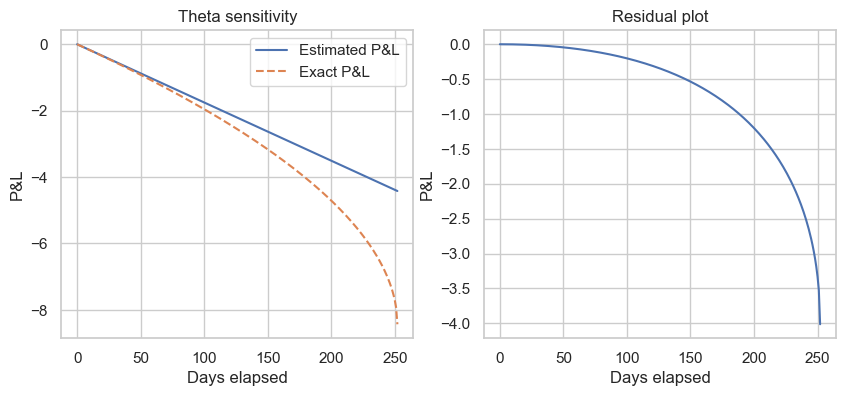

In [126]:
# Parameters
S = 100
K = 100
T = 1
r = 0.01
sigma = 0.2
dt_range = np.linspace(0,0.999999999999,252)

# Compute P&L
price_0 = black_scholes_prices(S, K, T, r, sigma, "call")
price_1 = black_scholes_prices(S, K, T-dt_range, r, sigma, "call")
pnl_exact = price_1 - price_0
pnl_estimate = [theta(S,K,T,r,sigma)*dt for dt in dt_range]

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(dt_range*252, pnl_estimate, label = "Estimated P&L")
plt.plot(dt_range*252, pnl_exact, linestyle = "--", label = "Exact P&L")
plt.title("Theta sensitivity")
plt.xlabel("Days elapsed")
plt.ylabel("P&L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dt_range*252, pnl_exact - pnl_estimate)
plt.title("Residual plot")
plt.xlabel("Days elapsed")
plt.ylabel("P&L")
plt.show()

- The Theta estimation is a straight line (it assumes that tomorrow's decay is the same as today), while exact P&L is a curve (As option gets closer to its expiration, the P&L decays).
- The difference is explained by the fact that time decay accelerates into expiration.
- "Free money" trap: Sellers (who have positive P&L from Theta) loves this curve because their income speeds up over time, while buyers hate it because their "rent" becomes more expensive every day they hold the position.

### 5.4 - Sensitivity to interest rate (Rho)

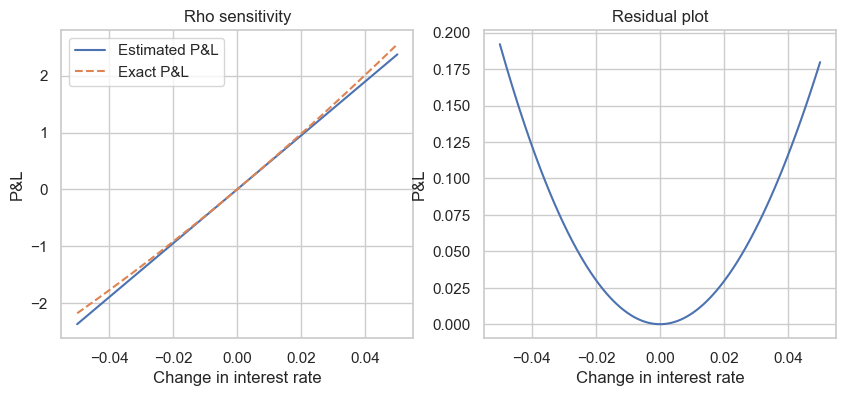

In [31]:
# Parameters
S = 100
K = 100
T = 1
r = 0.01
sigma = 0.2
dr_range = np.linspace(-0.05,0.05,100)

# Compute P&L
price_0 = black_scholes_prices(S, K, T, r, sigma, "call")
price_1 = black_scholes_prices(S, K, T, r+dr_range, sigma, "call")
pnl_exact = price_1 - price_0
pnl_estimate = [rho(S,K,T,r,sigma)*dr for dr in dr_range]

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(dr_range, pnl_estimate, label = "Estimated P&L")
plt.plot(dr_range, pnl_exact, linestyle = "--", label = "Exact P&L")
plt.title("Rho sensitivity")
plt.xlabel("Change in interest rate")
plt.ylabel("P&L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(dr_range, pnl_exact - pnl_estimate)
plt.title("Residual plot")
plt.xlabel("Change in interest rate")
plt.ylabel("P&L")
plt.show()

- Positive slope for a call, negative for a put.
- Time component: If we have smaller maturity, the line would be flat at 0 (because interest rate doesn't have time to compound in short-term options, so rho essentially dies as approaching expiration)

## Step 6 - Expiry Behavior (Gamma explosion)

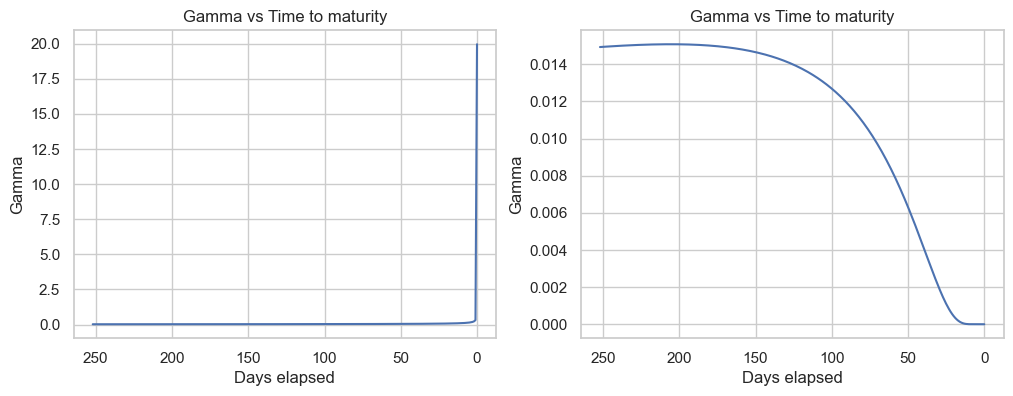

In [34]:
# Parameters
S = 100
K = 120
r = 0.01
sigma = 0.2
T_range = np.linspace(0.000001,1,252)

gamma_K_S = [gamma(S,S,t,r,sigma) for t in T_range] # ATM
gamma_K = [gamma(S,120,t,r,sigma) for t in T_range]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(T_range*252, gamma_K_S)
plt.title("Gamma vs Time to maturity")
plt.xlabel("Days elapsed")
plt.ylabel("Gamma")
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.plot(T_range*252, gamma_K)
plt.title("Gamma vs Time to maturity")
plt.xlabel("Days elapsed")
plt.ylabel("Gamma")
plt.gca().invert_xaxis()
plt.show()

**Mathematically**: From this graph, we see that Gamma explodes when expiring 0 at-the-money, but it's not the case for OTM/ITM.

**Intuition** : When far from maturity, the option has time to evolve. But when approaching maturity, the payoff is now $max(S-K;0)$ and the derivate of this function (is actually Gamma) is big, leading to a huge PnL just with a small variation of spot : $PnL \approx \Delta dS + \frac{1}{2}\Gamma dS^2$.

**Instable hedging**: We usually hedge with Delta, but when Gamma is big, Delta can change a lot. So we need to rebalance freqeuently since hedging error is rising, making transaction costs explode.

**Short gamma**: We lose if the market changes (up or down) and only earn if the market stays the same.

**Risk management**: When approaching expiration, the risk is not linear, PnL is highly sensible to changes, linear VaR is no longer valid and Greek estimation is no longer true. This is why, in reality, we have to reduce gamma positions before expiration or to take high premium for short-term option.

# BONUS: Advanced Risk Management

## Step 1 - Portfolio Construction

In [38]:
# Parameters
S = 100
r = 0.01
sigma = 0.2

# Example of a portfolio
portfolio = [
    {"type": "call", "K": 100, "T": 1, "qty": 10},
    {"type": "call", "K": 110, "T": 1, "qty": -5},
    {"type": "put", "K": 90, "T": 0.5, "qty": 7},
]

## Step 2 - Greek aggregation

$$\text{Net Greek}= \sum_i q_i \cdot \text{Greek}_i$$

In [68]:
# Initialization
net_delta = 0
net_gamma = 0
net_vega = 0
net_theta = 0
net_rho = 0
greek_contribution = []

# Aggregation
for p in portfolio:
    # Extract from portfolio
    typ = p["type"]
    Ki = p["K"]
    Ti = p["T"]
    q = p["qty"]

    # Compute the Greeks
    d = delta(S,Ki,Ti,r,sigma,typ)
    g = gamma(S,Ki,Ti,r,sigma)
    v = vega(S,Ki,Ti,r,sigma)
    t = theta(S,Ki,Ti,r,sigma,typ)
    rho_val = rho(S,Ki,Ti,r,sigma,typ)

    # Aggregation
    net_delta += q * d
    net_gamma += q * g
    net_vega += q * v
    net_theta += q * t
    net_rho += q * rho_val

    # Keeping aggregated values 
    greek_contribution.append({
        "K": K,
        "type": typ,
        "qty": q,
        "Delta": q*d,
        "Gamma": q*g,
        "Vega": q*v,
        "Theta": q*t,
        "Rho": q*rho_val
    })

# Display as data frame & print net greek
greeks_df = pd.DataFrame(greek_contribution)
print("Net Greeks:\n", pd.Series({
    "Delta": net_delta,
    "Gamma": net_gamma,
    "Vega": net_vega,
    "Theta": net_theta,
    "Rho": net_rho
}))
greeks_df

Net Greeks:
 Delta      2.354616
Gamma      0.240152
Vega     342.834460
Theta    -49.655793
Rho      237.436600
dtype: float64


,K,type,qty,Delta,Gamma,Vega,Theta,Rho
0,100,call,10,5.596177,0.197240,394.479331,-44.200778,475.284505
1,100,call,-5,-1.860019,-0.094557,-189.114343,20.540948,-162.951324
2,100,put,7,-1.381542,0.137469,137.469472,-25.995963,-74.896582


## Step 3 - Visualize Greek contribution

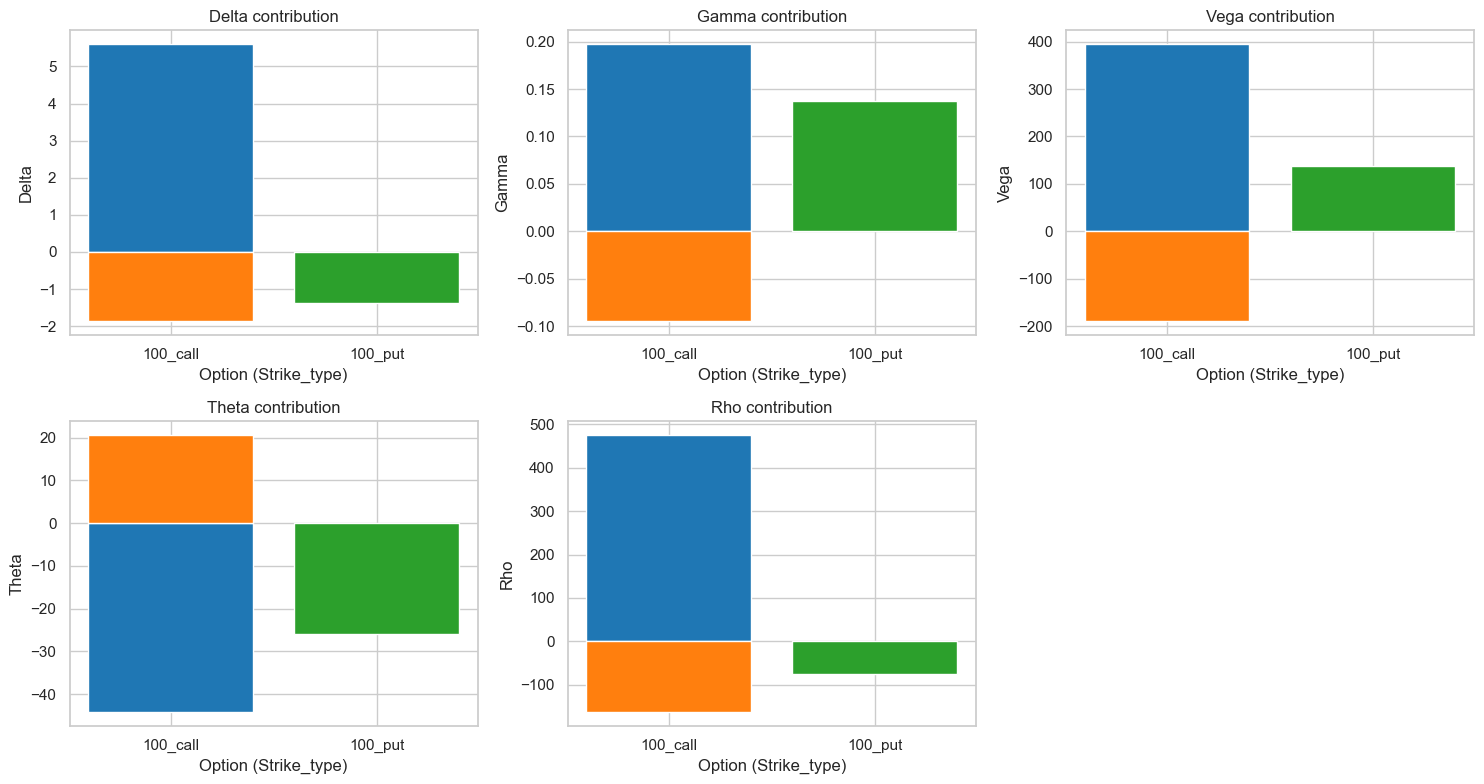

In [83]:
import matplotlib.cm as cm # to add colors

fig, axes = plt.subplots(2,3, figsize=(15,8))

# Define names & colors
greek_names = ["Delta","Gamma","Vega","Theta","Rho"]
colors = cm.tab10.colors # palette of 10 colors

# Bar plot
for i, name in enumerate(greek_names):
    # Iterate on position of plot
    ax = axes[i//3, i%3]

    # Assign a color for each option
    bar_colors = [colors[j % len(colors)] for j in range(len(greeks_df))]

    # Create bar plot
    ax.bar(greeks_df["K"].astype(str) + "_" + greeks_df["type"], greeks_df[name], color = bar_colors)
    ax.set_title(f"{name} contribution")
    ax.set_ylabel(name)
    ax.set_xlabel("Option (Strike_type)")

axes[1,2].axis("off")
plt.tight_layout()
plt.show()

- **Directional risk (Delta)**: A massive positive bar (in blue) for the call and a smaller negative bar (in green) for the put => This portfolio is long Delta, which means that it has a significant concentration risk to a downward move in the stock price (If stock price drops, the losses from the call will outweigh any gains from the put).
- **Convexity risk (Gamma)**: Gamma isn't usually seen as risk. Here, it just means that the P&L will be volatile, because a small move of stock will lead to large swings in Delta exposure.
- **Volatility risk (Gamma)**: Its contribution is highly positive, especially for the call => Long Vega => Risk towards the Volatility Crush (Since both bars are positive, we don't have a "hedge" for volatility == If implied volatility drop, the value of both positions decrease simutaneously).
- **Time Decay risk (Theta)**: Negative bars for both options => Bleeding risk (Every day that passes without a significant move in a stock or an increase in volatility, this portfolio loses money == Cost of carry for a high Vega and Delta exposure).
- **Interest Rate risk (Rho)**: Positive for the call and negative for the put => Positive Rho: This portfolio is sensitive to interest rate hikes (The scale up to 500 may suggest long-dated options, making the risk of a central bank change more significant than usual).

This looks like a Net Long Portfolio. The primary concentration risk is a "Quiet market", where the stock stays flat, volatility drops, and times passes. We are essentially paying Theta to bet on a massive move in stock price or volatility.

## Step 4 - Multi-Factor Stress Scenario

In [88]:
# Define shocks
dS = -0.05*S  # -5% spot
dsigma = 0.03 # +3% vol
dr = 0.005    # +50bps
dt = 5/252    # 5 days

# P&L using aggregated Greeks
pnl_approx = net_delta*dS + 0.5*net_gamma*dS**2 + net_vega*dsigma + net_theta*dt + net_rho*dr

# Exact P&L
pnl_exact = 0
for p in portfolio:
    # Extract from portfolio
    typ = p["type"]
    Ki = p["K"]
    Ti = p["T"]
    q = p["qty"]

    # Prices by BS
    price_0 = black_scholes_prices(S,Ki,Ti,r,sigma,typ)
    price_1 = black_scholes_prices(S+dS,Ki,Ti-dt,r+dr,sigma+dsigma,typ)
    pnl_exact += q*(price_1 - price_0)

print(f"Approx PnL (Greek): {pnl_approx:.2f}")
print(f"Exact PnL (Repricing): {pnl_exact:.2f}")
print(f"Residual: {pnl_exact - pnl_approx:.2f}")

Approx PnL (Greek): 1.72
Exact PnL (Repricing): 2.34
Residual: 0.63


- Greek approximation is different from exact repricing, showing that the book is non-linear.
- Large residual: Taylor expansions break and local linearization is insufficient, so risk is underestimated.

## Step 5 - Heatmap Visualization for Spot vs Vol Sensitivity

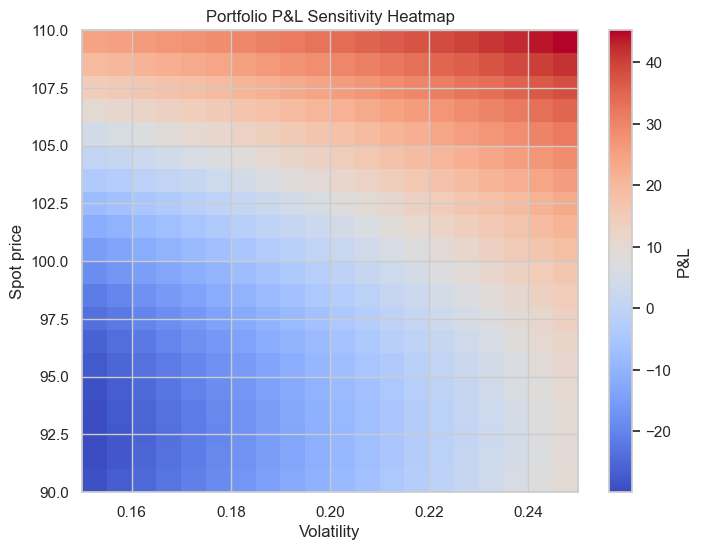

In [107]:
# Define ranges
spot_grid = np.linspace(90, 110, 20)
vol_grid = np.linspace(0.15, 0.25, 20)

# Matrix to stock P&L
pnl_matrix = np.zeros((len(spot_grid), len(vol_grid)))

# Compute P&L for each pair (spot, vol)
for i , S_val in enumerate(spot_grid):
    for j, vol_val in enumerate(vol_grid):
        # Compute P&L for a portfolio
        pnl = 0
        for p in portfolio:
            # Extract from portfolio
            typ = p["type"]
            Ki = p["K"]
            Ti = p["T"]
            q = p["qty"]

            # Compute exact P&L
            price_0 = black_scholes_prices(S,Ki,Ti,r,sigma,typ)
            price_1 = black_scholes_prices(S_val,Ki,Ti,r,vol_val,typ)
            pnl += q*(price_1 - price_0)

        # Fill in the matrix
        pnl_matrix[i,j] = pnl

# Plot heatmap
plt.figure(figsize=(8,6))
plt.imshow(pnl_matrix, origin="lower", extent=[vol_grid[0], vol_grid[-1], spot_grid[0], spot_grid[-1]], aspect="auto", cmap="coolwarm")
plt.colorbar(label="P&L")
plt.xlabel("Volatility")
plt.ylabel("Spot price")
plt.title("Portfolio P&L Sensitivity Heatmap")
plt.show()

- The portfolio is heavily dependent on the stock price going up: a long-stock bias.
- P&L improves and volatility increases (Vega contribution)
- The worst scenario is a volatility-crush combined with a price drop (bottomleft).
- Dead zone (white zone): The market stays exactly where it is, so we are slowly losing money due to the Theta concentration (paying for the chance to reach the red topright zone).

In conclusion, through risk contribution analysis, we know how evenly the risks are distributed (uniform risks are manageable). If concentrated, hedging P&L becomes noisy and unstable.